In [1]:
import numpy as np
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import os
import dill

import config as cfg 
import bdt_lh_cut_opt_with_n_interp as cutopt
plt.style.use('fcc.mplstyle')

import glob
import sys
import ROOT
import math
from tabulate import tabulate
from yaml import safe_load, YAMLError
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
 
import efficiency_finder

ROOT.EnableImplicitMT()



Welcome to JupyROOT 6.28/10


In [2]:
df = pd.read_pickle('/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/flavtag_dataframes/BF1e-06_selected_signal_flavtag_dataframe.pkl')

In [3]:
df

,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_vtx_isPV,decay
0,"[0.2391771823167801, 0.4018043875694275, 0.623...","[-0.19856300950050354, 0.23382149636745453, -0...","[0.10306636989116669, 0.32444068789482117, -0....","[-0.08459185063838959, -0.03889104723930359, -...","[0.22371844947338104, 0.3999178111553192, 0.24...","[-211.0, 211.0, -211.0, 211.0, -211.0, 321.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, ...","[0, 0, 0, 2, 2, -999, 2, 1, 1, 2, 0, 0, 0, 0, ...","[1, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
1,"[0.5991573333740234, 4.6365203857421875, 3.287...","[-0.5056517720222473, -4.339717388153076, -3.0...","[0.3041291832923889, 0.19282740354537964, 0.74...","[-0.10397713631391525, -1.6207993030548096, -1...","[0.5900663137435913, 4.34399938583374, 3.11186...","[211.0, -211.0, 211.0, -211.0, 211.0, -211.0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...","[-999, 2, 2, 2, 1, 1, 0, 0, 0, 0, -999, -999, ...","[1, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
2,"[0.1983632892370224, 0.6613348722457886, 0.944...","[-0.19296784698963165, 0.44998642802238464, -0...","[0.04428353160619736, -0.15479542315006256, 0....","[-0.012262613512575626, -0.4592541456222534, -...","[0.19798389077186584, 0.47586700320243835, 0.9...","[-211.0, 211.0, -211.0, 211.0, 211.0, -211.0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 1, 0, 0, -999, 2, 2, 0, 0, 2, 0, 0, ...","[1, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
3,"[0.5739926695823669, 0.5703606605529785, 0.843...","[0.05662541463971138, -0.09014341980218887, -0...","[0.49913033843040466, 0.5304792523384094, -0.6...","[-0.2777229845523834, -0.18914860486984253, -0...","[0.5023320913314819, 0.5380837321281433, 0.832...","[211.0, -211.0, 211.0, 211.0, -211.0, -211.0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, ...","[0, 0, 1, 3, 2, 2, 2, 3, 0, 0, 3, 1, -999, -99...","[1, 0, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
4,"[2.378901481628418, 2.511718988418579, 0.70233...","[-0.9254810214042664, 1.5053701400756836, 0.43...","[-0.5020391941070557, -0.012135084718465805, 0...","[-2.1332168579101562, 2.0105834007263184, 0.52...","[1.0528810024261475, 1.505419135093689, 0.4619...","[321.0, 211.0, 211.0, -211.0, -321.0, 211.0, 2...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 2, 3, 1, 3, 2, 0, 2, 2, 2, 0, 1, 2, 0, -99...","[1, 0, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
...,...,...,...,...,...,...,...,...,...,...
756733,"[0.2763315439224243, 0.9377710223197937, 0.551...","[-0.15659821033477783, -0.3878803253173828, 0....","[-0.08539073914289474, -0.020035255700349808, ...","[-0.21105578541755676, -0.853558361530304, -0....","[0.17836642265319824, 0.3883974254131317, 0.33...","[-211.0, 211.0, -211.0, 211.0, -211.0, 211.0, ...","[1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, ...","[1, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
756734,"[0.4774807393550873, 3.613682270050049, 0.9737...","[-0.23249800503253937, 2.2875301837921143, 0.3...","[-0.04053895175457001, 1.2579096555709839, -0....","[-0.415077269077301, -2.498713254928589, -0.59...","[0.2360057830810547, 2.6105806827545166, 0.772...","[211.0, -211.0, 211.0, 211.0, 211.0, 211.0, 21...","[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 2, 1, 1, 2, 0, 1, 2, 2, 1, 1, ...","[1, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
756735,"[0.32267168164253235, 0.7931380867958069, 0.72...","[0.06213269755244255, -0.10685354471206665, 0....","[-0.26923370361328125, 0.7358892560005188, -0....","[-0.16664257645606995, -0.2758936583995819, -0...","[0.2763100862503052, 0.7436065077781677, 0.705...","[211.0, 211.0, 211.0, 321.0, -211.0, 211.0, 11...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, ...","[0, 0, 0, 0, 0, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0]",p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
756736,"[0.23003695905208588, 0.4957648813724518, 0.67...","[0.04701455682516098, -0.3270357847213745, 0.5...","[0.1419510394334793, -0.1215631514787674

In [4]:
df.iloc[1]['Rec_p']

[0.5991573333740234,
 4.6365203857421875,
 3.287721872329712,
 10.349098205566406,
 9.15461540222168,
 0.750067949295044,
 3.371424913406372,
 0.7130186557769775,
 2.1793534755706787,
 3.3792154788970947,
 0.24847710132598877,
 0.4283297657966614,
 0.7144026756286621,
 0.3845813572406769,
 1.202675700187683,
 3.4004125595092773,
 3.4492177963256836,
 0.23561708629131317,
 0.7954108715057373,
 0.5315521359443665,
 0.7608098387718201,
 1.155587911605835,
 0.4769953787326813,
 0.2547520697116852]

In [5]:
#keep desired branches
flavtag_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_vtx_isPV", "decay" ] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"
reco_space_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx"] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"

dfbs = df.head(40000)
dfbd = df.tail(40000).reset_index(drop=True)


In [6]:
#keep desired branches

df_dict ={}
key = ['bs','bd']
for s in range(2):
    df = [dfbs,dfbd][s]

    pv=[]
    #create empty dfs to fill
    filtered_df = pd.DataFrame(columns= reco_space_branches )
    filtered_df_fully = pd.DataFrame(columns= reco_space_branches )
    #loop through events
    for i in range(len(df["Rec_p"])):
        evt = df.iloc[i]
        mask = (np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 321)| (np.array(np.round(evt['Rec_true_PDG'])) == -321))
        for var in reco_space_branches:
            filtered_df.loc[i, var] = np.array(evt[var])[mask]
        
        from_PV=[]
        for k in range(len(filtered_df['Rec_indvtx'][i])):
            if filtered_df['Rec_indvtx'][i][k] == -999:
                from_PV.append(0)
            else:
                from_PV.append(np.array(df['Rec_vtx_isPV'][i])[filtered_df['Rec_indvtx'][i][k]])
        pv.append(from_PV)
        mask = np.array(from_PV)==1
        for var in reco_space_branches:
            filtered_df_fully.loc[i, var] = filtered_df.loc[i, var][mask]

    df_dict[key[s]] = filtered_df_fully


    

In [7]:
dfbs = df_dict['bs']

In [8]:
dfbd = df_dict['bd']

In [9]:
maxp_K_bs =[np.max(dfbs['Rec_p'][i]) if len(dfbs['Rec_p'][i]) != 0 else -1 for i in range(len(dfbs))]
maxp_K_bd =[np.max(dfbd['Rec_p'][i]) if len(dfbd['Rec_p'][i]) != 0 else -1 for i in range(len(dfbd))]

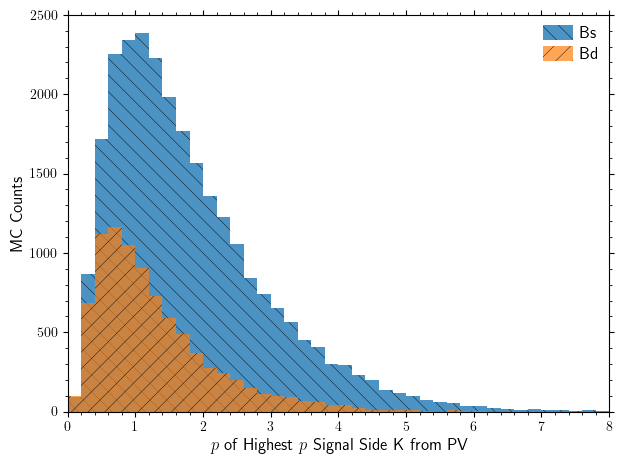

In [69]:
plt.hist(maxp_K_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8))
plt.hist(maxp_K_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8))
plt.xlim(0,8)
plt.ylim(0,2500)
plt.xlabel('$p$ of Highest $p$ Signal Side K from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

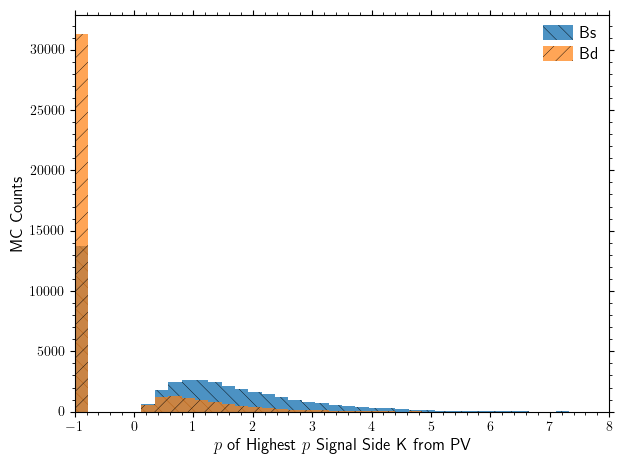

In [70]:
plt.hist(maxp_K_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(-1,8))
plt.hist(maxp_K_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(-1,8))
plt.xlabel('$p$ of Highest $p$ Signal Side K from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

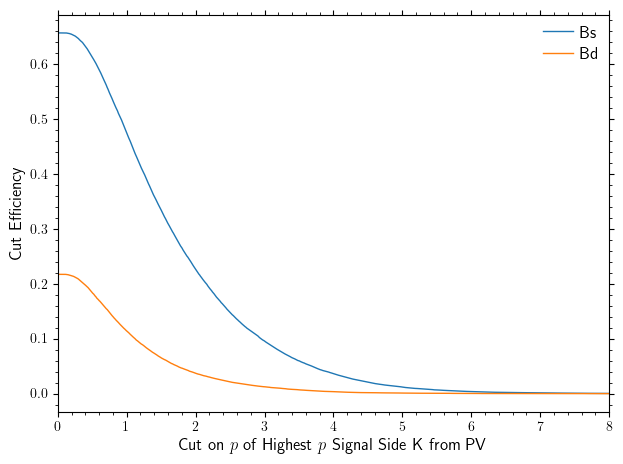

In [54]:
n_remaining_bs = []
n_remaining_bd = []
cut_arr = []
for i in np.linspace(0,max(maxp_K_bs),1000):
    filter_bs_arr = np.array(maxp_K_bs) >i
    filter_bd_arr= np.array(maxp_K_bd) >i
    n_remaining_bs.append(len(np.array(maxp_K_bs)[filter_bs_arr])/len(maxp_K_bs))
    n_remaining_bd.append(len(np.array(maxp_K_bd)[filter_bd_arr])/len(maxp_K_bd))
    cut_arr.append(i)
plt.plot(cut_arr,n_remaining_bs,label='Bs') 
plt.plot(cut_arr,n_remaining_bd,label='Bd') 
plt.xlim(0,8)
plt.legend()
plt.xlabel('Cut on $p$ of Highest $p$ Signal Side K from PV')
plt.ylabel('Cut Efficiency')
plt.show()

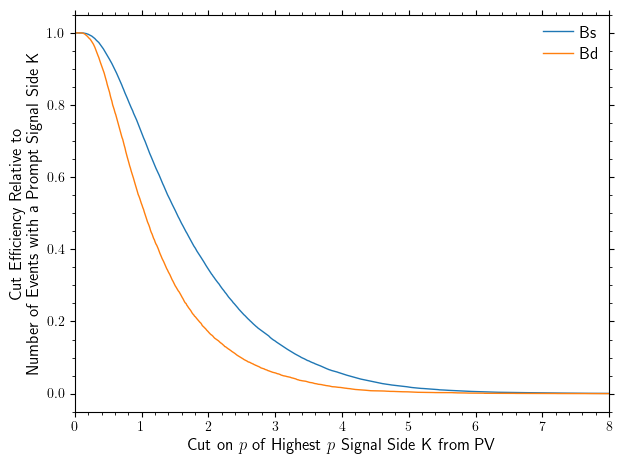

In [67]:
# if ignore ones where no K
n_remaining_bs_norm  = []
n_remaining_bd_norm  = []
cut_arr = []

filter_bs_arr0 = np.array(maxp_K_bs) >=0
filter_bd_arr0= np.array(maxp_K_bd) >=0

bs_arr0 = np.array(maxp_K_bs)[filter_bs_arr0]
bd_arr0 = np.array(maxp_K_bd)[filter_bd_arr0]

for i in np.linspace(0,max(maxp_K_bs),1000):
    filter_bs_arr = np.array(maxp_K_bs) >i
    filter_bd_arr= np.array(maxp_K_bd) >i
    n_remaining_bs_norm .append(len(np.array(maxp_K_bs)[filter_bs_arr])/len(bs_arr0))
    n_remaining_bd_norm .append(len(np.array(maxp_K_bd)[filter_bd_arr])/len(bd_arr0))
    cut_arr.append(i)
plt.plot(cut_arr,n_remaining_bs_norm ,label='Bs') 
plt.plot(cut_arr,n_remaining_bd_norm ,label='Bd') 
plt.xlim(0,8)
plt.xlabel('Cut on $p$ of Highest $p$ Signal Side K from PV')
plt.ylabel('Cut Efficiency Relative to \n Number of Events with a Prompt Signal Side K')
plt.legend()
plt.show()

In [56]:
maxpt_K_bs =[np.max(dfbs['Rec_pt'][i]) if len(dfbs['Rec_pt'][i]) != 0 else -1 for i in range(len(dfbs))]
maxpt_K_bd =[np.max(dfbd['Rec_pt'][i]) if len(dfbd['Rec_pt'][i]) != 0 else -1 for i in range(len(dfbd))]

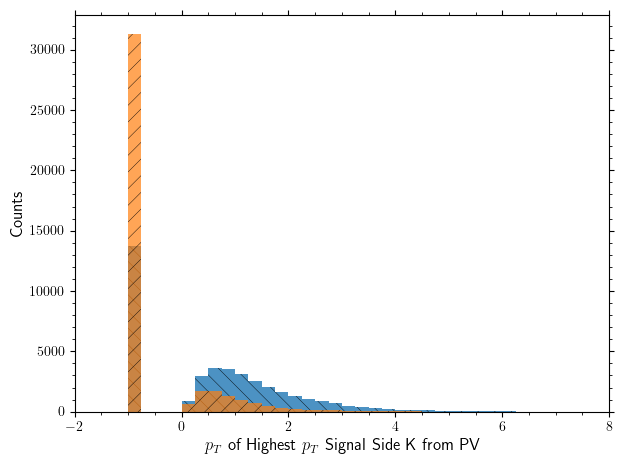

In [57]:
plt.hist(maxpt_K_bs,bins=40, alpha = 0.8, hatch='\\\\',range=(-2,8))
plt.hist(maxpt_K_bd,bins=40, alpha = 0.7, hatch='//',range=(-2,8))
plt.xlabel('$p_T$ of Highest $p_T$ Signal Side K from PV')
plt.ylabel('Counts')
plt.show()

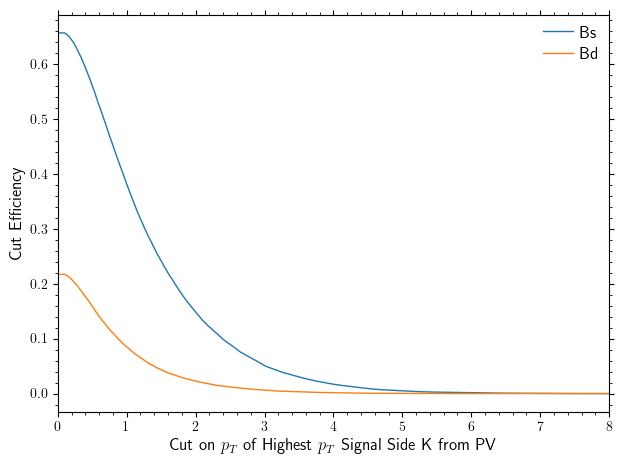

In [58]:
n_remaining_bs_pt = []
n_remaining_bd_pt = []
cut_arr = []
for i in np.linspace(0,max(maxpt_K_bs),1000):
    filter_bs_arr = np.array(maxpt_K_bs) >i
    filter_bd_arr= np.array(maxpt_K_bd) >i
    n_remaining_bs_pt.append(len(np.array(maxpt_K_bs)[filter_bs_arr])/len(maxpt_K_bs))
    n_remaining_bd_pt.append(len(np.array(maxpt_K_bd)[filter_bd_arr])/len(maxpt_K_bd))
    cut_arr.append(i)
plt.plot(cut_arr,n_remaining_bs_pt,label='Bs') 
plt.plot(cut_arr,n_remaining_bd_pt,label='Bd') 
plt.xlim(0,8)
plt.xlabel('Cut on $p_T$ of Highest $p_T$ Signal Side K from PV')
plt.ylabel('Cut Efficiency')
plt.legend()
plt.show()

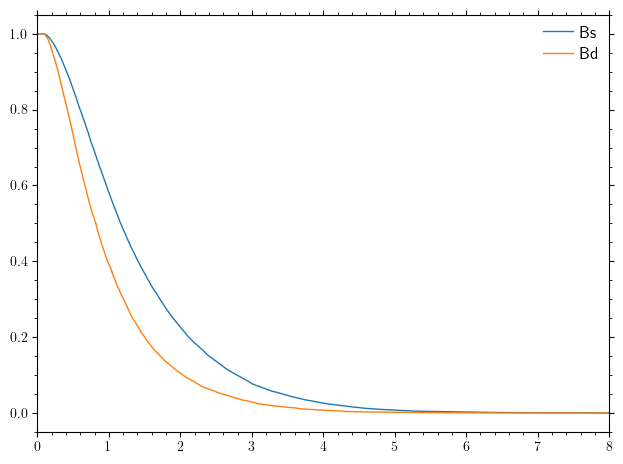

In [68]:
# if ignore ones where no K
n_remaining_bs_pt_norm = []
n_remaining_bd_pt_norm  = []
cut_arr = []

filter_bs_arr0 = np.array(maxpt_K_bs) >=0
filter_bd_arr0= np.array(maxpt_K_bd) >=0

bs_arr0 = np.array(maxpt_K_bs)[filter_bs_arr0]
bd_arr0 = np.array(maxpt_K_bd)[filter_bd_arr0]

for i in np.linspace(0,max(maxpt_K_bs),1000):
    filter_bs_arr = np.array(maxpt_K_bs) >i
    filter_bd_arr= np.array(maxpt_K_bd) >i
    n_remaining_bs_pt_norm .append(len(np.array(maxpt_K_bs)[filter_bs_arr])/len(bs_arr0))
    n_remaining_bd_pt_norm .append(len(np.array(maxpt_K_bd)[filter_bd_arr])/len(bd_arr0))
    cut_arr.append(i)
plt.plot(cut_arr,n_remaining_bs_pt_norm ,label='Bs') 
plt.plot(cut_arr,n_remaining_bd_pt_norm ,label='Bd') 
plt.xlim(0,8)
plt.legend()
plt.show()

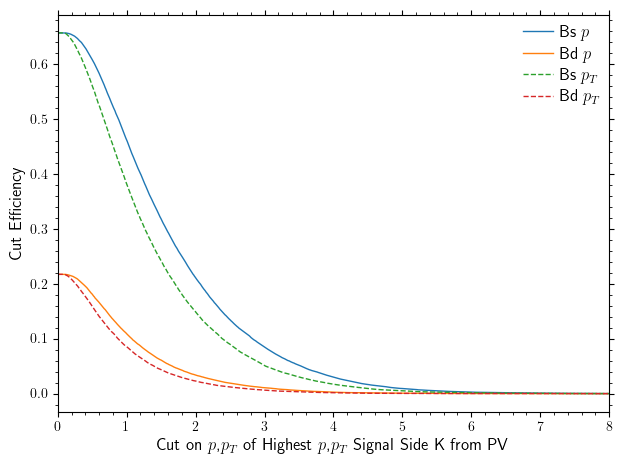

In [66]:
plt.plot(cut_arr,n_remaining_bs,label='Bs $p$ ') 
plt.plot(cut_arr,n_remaining_bd,label='Bd $p$ ') 
plt.plot(cut_arr,n_remaining_bs_pt,label='Bs $p_T$ ',linestyle='dashed') 
plt.plot(cut_arr,n_remaining_bd_pt,label='Bd $p_T$ ', linestyle='dashed') 
plt.xlim(0,8)
plt.xlabel('Cut on {$p$,$p_T$} of Highest {$p$,$p_T$} Signal Side K from PV')
plt.ylabel('Cut Efficiency')
plt.legend()
plt.show()

In [71]:
num_K_bs =[len(dfbs['Rec_p'][i]) for i in range(len(dfbs))]
num_K_bd =[len(dfbd['Rec_p'][i]) for i in range(len(dfbd))]

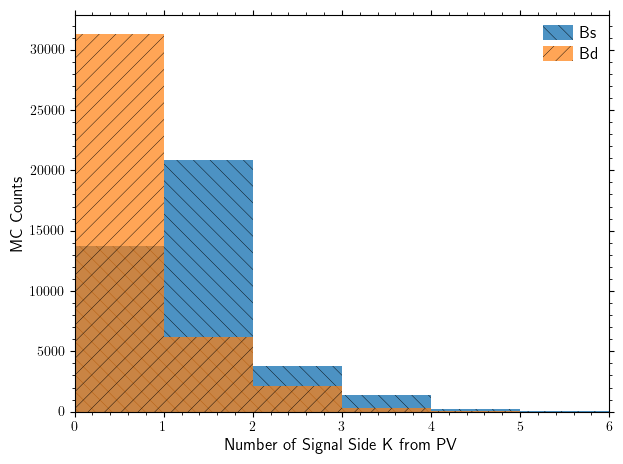

In [74]:
plt.hist(num_K_bs,bins=6, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,6))
plt.hist(num_K_bd,bins=6, alpha = 0.7, hatch='//',label='Bd',range=(0,6))
plt.xlabel('Number of Signal Side K from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

In [75]:
df = pd.read_pickle('/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/flavtag_dataframes/BF1e-06_selected_signal_flavtag_dataframe.pkl')

#keep desired branches
flavtag_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_vtx_isPV", "decay" ] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"
reco_space_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx"] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"

dfbs = df.head(5000)
dfbd = df.tail(5000).reset_index(drop=True)


df_dict ={}
key = ['bs','bd']
for s in range(2):
    df = [dfbs,dfbd][s]

    pv=[]
    #create empty dfs to fill
    filtered_df = pd.DataFrame(columns= reco_space_branches )
    filtered_df_fully = pd.DataFrame(columns= reco_space_branches )
    #loop through events
    for i in range(len(df["Rec_p"])):
        evt = df.iloc[i]
        mask = (np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 211)| (np.array(np.round(evt['Rec_true_PDG'])) == -211)|(np.array(np.round(evt['Rec_true_PDG'])) == 2212)| (np.array(np.round(evt['Rec_true_PDG'])) == -2212))
        for var in reco_space_branches:
            filtered_df.loc[i, var] = np.array(evt[var])[mask]
        
        from_PV=[]
        for k in range(len(filtered_df['Rec_indvtx'][i])):
            if filtered_df['Rec_indvtx'][i][k] == -999:
                from_PV.append(0)
            else:
                from_PV.append(np.array(df['Rec_vtx_isPV'][i])[filtered_df['Rec_indvtx'][i][k]])
        pv.append(from_PV)
        mask = np.array(from_PV)==1
        for var in reco_space_branches:
            filtered_df_fully.loc[i, var] = filtered_df.loc[i, var][mask]

    df_dict[key[s]] = filtered_df_fully


dfbs = df_dict['bs']
dfbd = df_dict['bd']


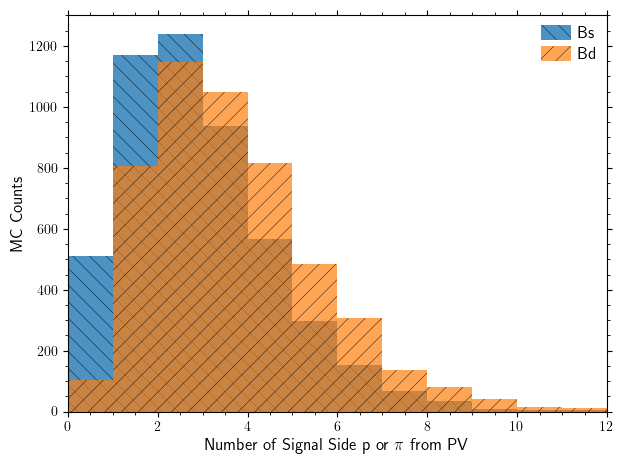

In [79]:
num_pip_bs =[len(dfbs['Rec_p'][i]) for i in range(len(dfbs))]
num_pip_bd =[len(dfbd['Rec_p'][i]) for i in range(len(dfbd))]
plt.hist(num_pip_bs,bins=12, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,12))
plt.hist(num_pip_bd,bins=12, alpha = 0.7, hatch='//',label='Bd',range=(0,12))
plt.xlabel('Number of Signal Side p or $\pi$ from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

In [78]:
maxp_pip_bs =[np.max(dfbs['Rec_p'][i]) if len(dfbs['Rec_p'][i]) != 0 else -1 for i in range(len(dfbs))]
maxp_pip_bd =[np.max(dfbd['Rec_p'][i]) if len(dfbd['Rec_p'][i]) != 0 else -1 for i in range(len(dfbd))]

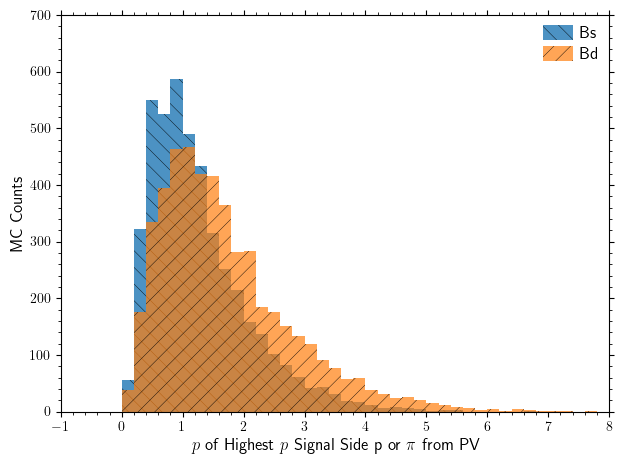

In [84]:
plt.hist(maxp_pip_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8))
plt.hist(maxp_pip_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8))
plt.xlim(-1,8)
plt.ylim(0,700)
plt.xlabel('$p$ of Highest $p$ Signal Side p or $\pi$ from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

In [95]:
df = pd.read_pickle('/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/flavtag_dataframes/BF1e-06_selected_signal_flavtag_dataframe.pkl')

#keep desired branches
flavtag_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_vtx_isPV", "decay" ] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"
reco_space_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx"] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"

dfbs = df.head(5000)
dfbd = df.tail(5000).reset_index(drop=True)


df_dict ={}
key = ['bs','bd']
for s in range(2):
    df = [dfbs,dfbd][s]

    pv=[]
    #create empty dfs to fill
    filtered_df = pd.DataFrame(columns= reco_space_branches )
    filtered_df_fully = pd.DataFrame(columns= reco_space_branches )
    #loop through events
    for i in range(len(df["Rec_p"])):
        evt = df.iloc[i]
        mask = (np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 211)| (np.array(np.round(evt['Rec_true_PDG'])) == -211))
        for var in reco_space_branches:
            filtered_df.loc[i, var] = np.array(evt[var])[mask]
        
        from_PV=[]
        for k in range(len(filtered_df['Rec_indvtx'][i])):
            if filtered_df['Rec_indvtx'][i][k] == -999:
                from_PV.append(0)
            else:
                from_PV.append(np.array(df['Rec_vtx_isPV'][i])[filtered_df['Rec_indvtx'][i][k]])
        pv.append(from_PV)
        mask = np.array(from_PV)==1
        for var in reco_space_branches:
            filtered_df_fully.loc[i, var] = filtered_df.loc[i, var][mask]

    df_dict[key[s]] = filtered_df_fully


dfbs = df_dict['bs']
dfbd = df_dict['bd']

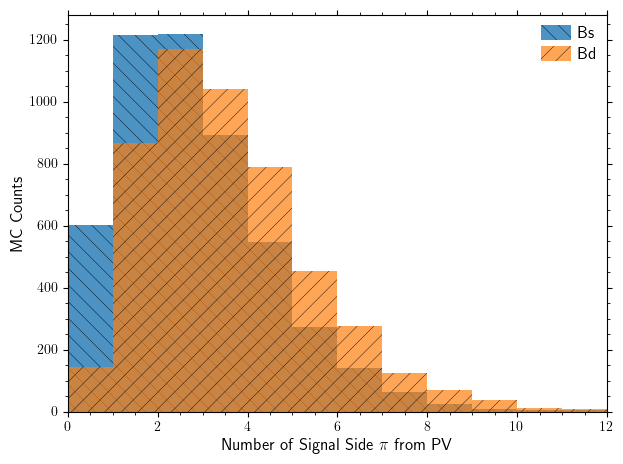

In [96]:
num_pi_bs =[len(dfbs['Rec_p'][i]) for i in range(len(dfbs))]
num_pi_bd =[len(dfbd['Rec_p'][i]) for i in range(len(dfbd))]
plt.hist(num_pi_bs,bins=12, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,12))
plt.hist(num_pi_bd,bins=12, alpha = 0.7, hatch='//',label='Bd',range=(0,12))
plt.xlabel('Number of Signal Side $\pi$ from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

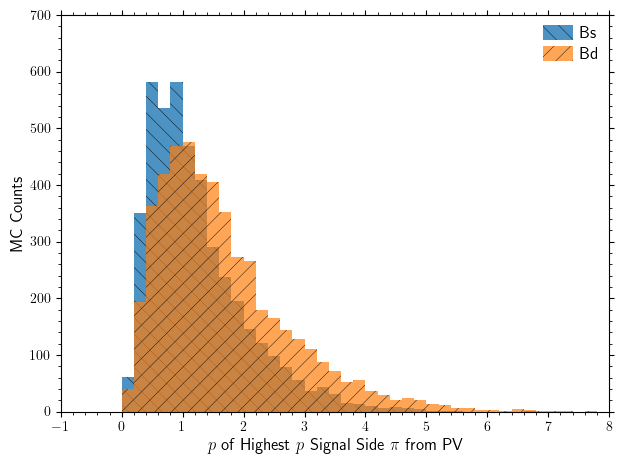

In [97]:
maxp_pi_bs =[np.max(dfbs['Rec_p'][i]) if len(dfbs['Rec_p'][i]) != 0 else -1 for i in range(len(dfbs))]
maxp_pi_bd =[np.max(dfbd['Rec_p'][i]) if len(dfbd['Rec_p'][i]) != 0 else -1 for i in range(len(dfbd))]
plt.hist(maxp_pi_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8))
plt.hist(maxp_pi_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8))
plt.xlim(-1,8)
plt.ylim(0,700)
plt.xlabel('$p$ of Highest $p$ Signal Side $\pi$ from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

In [88]:
df = pd.read_pickle('/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/flavtag_dataframes/BF1e-06_selected_signal_flavtag_dataframe.pkl')

#keep desired branches
flavtag_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_vtx_isPV", "decay" ] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"
reco_space_branches = ["Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx"] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"

dfbs = df.head(5000)
dfbd = df.tail(5000).reset_index(drop=True)


df_dict ={}
key = ['bs','bd']
for s in range(2):
    df = [dfbs,dfbd][s]

    pv=[]
    #create empty dfs to fill
    filtered_df = pd.DataFrame(columns= reco_space_branches )
    filtered_df_fully = pd.DataFrame(columns= reco_space_branches )
    #loop through events
    for i in range(len(df["Rec_p"])):
        evt = df.iloc[i]
        mask = (np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 2212)| (np.array(np.round(evt['Rec_true_PDG'])) == -2212))
        for var in reco_space_branches:
            filtered_df.loc[i, var] = np.array(evt[var])[mask]
        
        from_PV=[]
        for k in range(len(filtered_df['Rec_indvtx'][i])):
            if filtered_df['Rec_indvtx'][i][k] == -999:
                from_PV.append(0)
            else:
                from_PV.append(np.array(df['Rec_vtx_isPV'][i])[filtered_df['Rec_indvtx'][i][k]])
        pv.append(from_PV)
        mask = np.array(from_PV)==1
        for var in reco_space_branches:
            filtered_df_fully.loc[i, var] = filtered_df.loc[i, var][mask]

    df_dict[key[s]] = filtered_df_fully


dfbs = df_dict['bs']
dfbd = df_dict['bd']

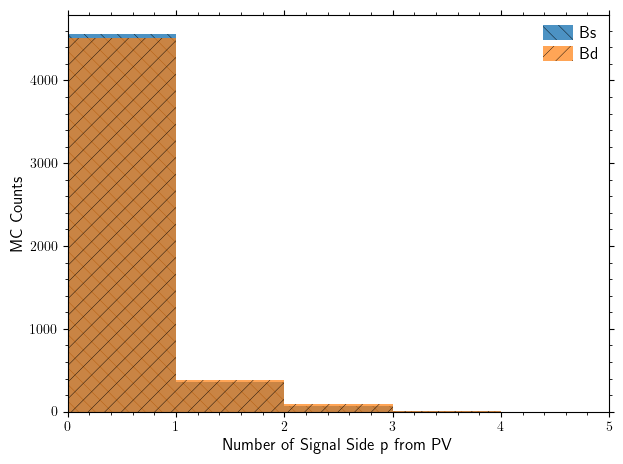

In [94]:
num_p_bs =[len(dfbs['Rec_p'][i]) for i in range(len(dfbs))]
num_p_bd =[len(dfbd['Rec_p'][i]) for i in range(len(dfbd))]
plt.hist(num_p_bs,bins=5, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,5))
plt.hist(num_p_bd,bins=5, alpha = 0.7, hatch='//',label='Bd',range=(0,5))
plt.xlabel('Number of Signal Side p from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()

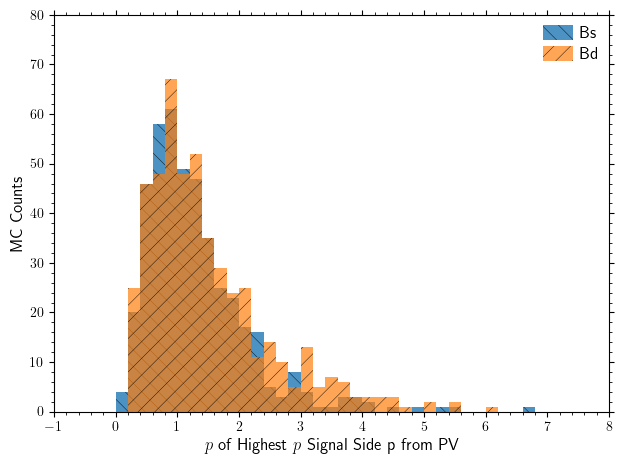

In [93]:
maxp_p_bs =[np.max(dfbs['Rec_p'][i]) if len(dfbs['Rec_p'][i]) != 0 else -1 for i in range(len(dfbs))]
maxp_p_bd =[np.max(dfbd['Rec_p'][i]) if len(dfbd['Rec_p'][i]) != 0 else -1 for i in range(len(dfbd))]
plt.hist(maxp_p_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8))
plt.hist(maxp_p_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8))
plt.xlim(-1,8)
plt.ylim(0,80)
plt.xlabel('$p$ of Highest $p$ Signal Side p from PV')
plt.ylabel('MC Counts')
plt.legend()
plt.show()